# 🏠 House Price Prediction Using Linear Regression

## Project Overview

This project builds an end-to-end **Machine Learning regression workflow** to predict house values using the California Housing dataset.

### Objectives
- Load and understand the dataset
- Perform data quality checks
- Explore relationships between features and house prices
- Create useful derived features
- Split the data into training and testing sets
- Standardize numerical features
- Train a Linear Regression model
- Evaluate model performance
- Extract practical business insights

> **Note:** The target variable is `MedHouseVal`, the median house value in units used by the California Housing dataset.

In [1]:
# Import libraries for data manipulation, numerical operations, visualization,
# and access to the California Housing dataset.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset as a pandas-friendly object.
housing = fetch_california_housing(as_frame=True)

# Copy the complete dataset into a DataFrame so that the original
# sklearn dataset object remains unchanged.
df = housing.frame.copy()

# Preview the first five observations.
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Dataset Overview

Before modeling, we inspect the dataset structure, dimensions, data types, summary statistics, and available numerical features.

In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [19]:
# Inspect the column names, non-null counts, data types, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MedInc           20640 non-null  float64
 1   HouseAge         20640 non-null  float64
 2   AveRooms         20640 non-null  float64
 3   AveBedrms        20640 non-null  float64
 4   Population       20640 non-null  float64
 5   AveOccup         20640 non-null  float64
 6   Latitude         20640 non-null  float64
 7   Longitude        20640 non-null  float64
 8   MedHouseVal      20640 non-null  float64
 9   RoomsPerPerson   20640 non-null  float64
 10  BedroomsPerRoom  20640 non-null  float64
dtypes: float64(11)
memory usage: 1.7 MB


In [20]:
# Generate descriptive statistics to understand the distribution and scale of each numerical feature.
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerPerson,BedroomsPerRoom
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558,1.976970,0.213075
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956,1.146020,0.058023
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990,0.002547,0.100000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000,1.522382,0.175426
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000,1.937936,0.203181
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250,2.296090,0.239834
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010,55.222222,1.000000


In [21]:
# Identify all numerical columns available for analysis.
df.select_dtypes(include=["number"]).columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerPerson',
       'BedroomsPerRoom'],
      dtype='object')

## 2. Data Quality Checks

The next checks verify whether the dataset contains missing values, duplicate rows, or unexpected data types.

In [22]:
# Check for missing values in every column.
df.isnull().sum()

MedInc             0
HouseAge           0
AveRooms           0
AveBedrms          0
Population         0
AveOccup           0
Latitude           0
Longitude          0
MedHouseVal        0
RoomsPerPerson     0
BedroomsPerRoom    0
dtype: int64

In [23]:
# Check for completely duplicated rows.
df.duplicated().sum()

np.int64(0)

In [24]:
# Confirm the data type of each column.
df.dtypes

MedInc             float64
HouseAge           float64
AveRooms           float64
AveBedrms          float64
Population         float64
AveOccup           float64
Latitude           float64
Longitude          float64
MedHouseVal        float64
RoomsPerPerson     float64
BedroomsPerRoom    float64
dtype: object

## 3. Exploratory Data Analysis

### Correlation Analysis

Correlation helps us understand the **strength and direction of linear relationships** between numerical variables.

A correlation close to +1 indicates a strong positive linear relationship, while a value close to -1 indicates a strong negative linear relationship.

> Correlation does **not** prove causation.

In [25]:
# Calculate pairwise correlations between numerical variables.
df.corr(numeric_only=True)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerPerson,BedroomsPerRoom
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075,0.237828,-0.615479
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623,-0.107926,0.136367
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948,0.887282,-0.418704
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701,0.824678,0.055817
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650,-0.140520,0.037075
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737,-0.053906,0.002881
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160,0.140345,-0.114302
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967,-0.074420,0.092868
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000,0.209482,-0.255624
RoomsPerPerson,0.237828,-0.107926,0.887282,0.824678,-0.140520,-0.053906,0.140345,-0.074420,0.209482,1.000000,-0.273808


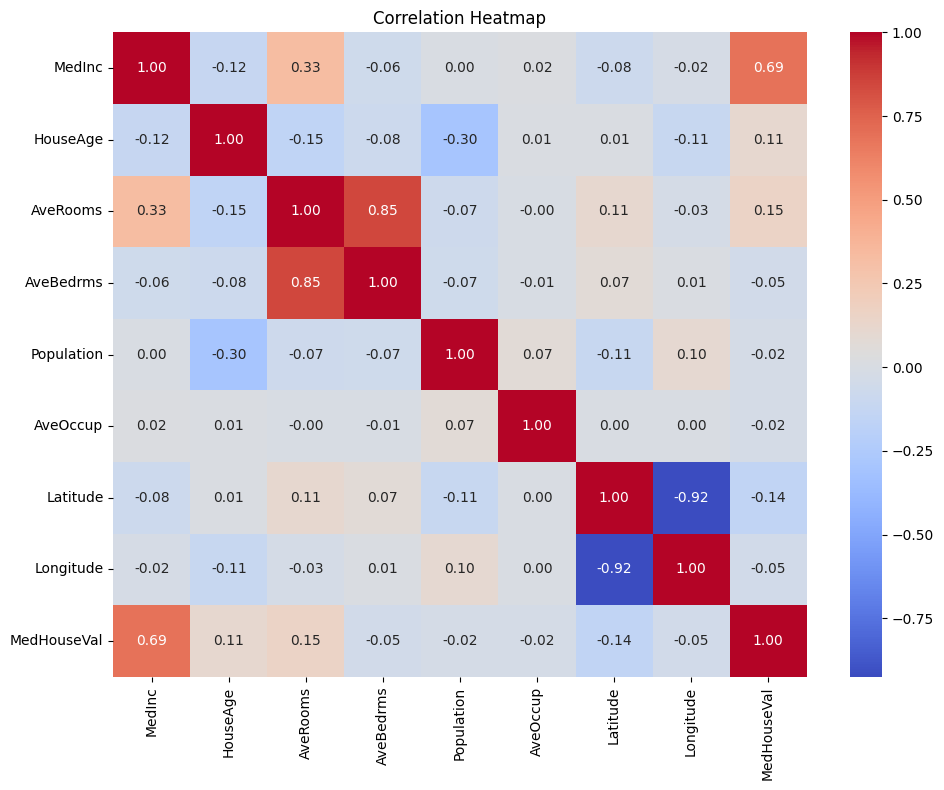

In [10]:
# Visualize correlations between all numerical variables.
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

# Save the figure so it can also be used in the GitHub project.
plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

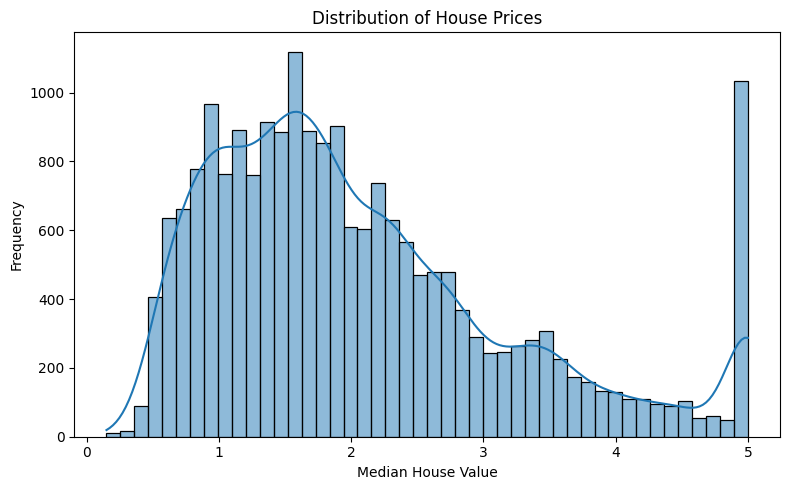

In [11]:
# Inspect the distribution of the target variable, MedHouseVal.
plt.figure(figsize=(8, 5))

sns.histplot(df["MedHouseVal"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.tight_layout()

# Save the visualization for documentation/portfolio use.
plt.savefig("house_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

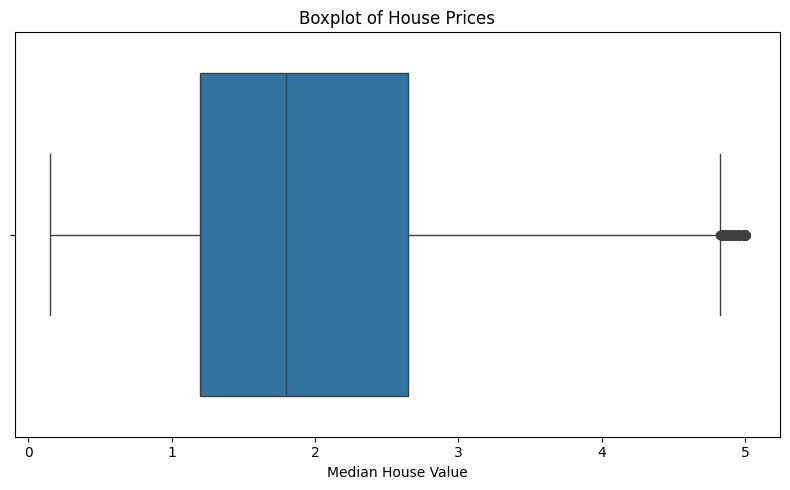

In [12]:
# Use a boxplot to visually inspect the target variable for extreme observations.
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MedHouseVal"])

plt.title("Boxplot of House Prices")
plt.xlabel("Median House Value")
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Two ratio-based features are created to provide additional information that is not directly represented by the original columns:

- `RoomsPerPerson` — average rooms relative to average occupancy
- `BedroomsPerRoom` — average bedrooms relative to average rooms

These features are simple domain-inspired transformations intended to help the model capture potentially useful relationships.

In [13]:
# Feature 1: approximate number of rooms available per occupant.
df["RoomsPerPerson"] = df["AveRooms"] / df["AveOccup"]

# Feature 2: proportion of average bedrooms relative to average rooms.
df["BedroomsPerRoom"] = df["AveBedrms"] / df["AveRooms"]

# Verify that the new features were created successfully.
df[["RoomsPerPerson", "BedroomsPerRoom"]].head()

,RoomsPerPerson,BedroomsPerRoom
0,2.732919,0.146591
1,2.956685,0.155797
2,2.957661,0.129516
3,2.283154,0.184458
4,2.879646,0.172096


In [14]:
# The two engineered features are now part of the feature set used by the model.
df[["RoomsPerPerson", "BedroomsPerRoom"]].describe()

,RoomsPerPerson,BedroomsPerRoom
count,20640.000000,20640.000000
mean,1.976970,0.213075
std,1.146020,0.058023
min,0.002547,0.100000
25%,1.522382,0.175426
50%,1.937936,0.203181
75%,2.296090,0.239834
max,55.222222,1.000000


## 5. Train-Test Split and Feature Scaling

The target is `MedHouseVal`.

We use an **80/20 train-test split**:
- 80% for training
- 20% for testing

`StandardScaler` is fitted **only on the training data** and then applied to both training and test data. This prevents information from the test set from influencing the scaling process.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate input features (X) from the target variable (y).
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Split the dataset into training and testing subsets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create the scaler.
scaler = StandardScaler()

# Fit the scaler only on the training data.
X_train_scaled = scaler.fit_transform(X_train)

# Apply the already-fitted scaler to the test data.
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 10)
X_test : (4128, 10)
y_train: (16512,)
y_test : (4128,)


## 6. Model Building — Linear Regression

Linear Regression is used as the first baseline model.

The model learns a linear relationship between the input features and the target house value.

In [16]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model.
model = LinearRegression()

# Train the model using the scaled training features and training targets.
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.79, 0.13,-0.15,...,-0.83, 0.52, 0.24]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[221.19,179.12,162.5 ,..., 46.98, 30.27, 20.07]"


## 7. Predictions

The trained model is used to predict house values for the unseen test set.

Comparing predictions with actual values helps us understand how well the model generalizes to unseen data.

In [17]:
# Generate predictions for the test dataset.
y_pred = model.predict(X_test_scaled)

# Display a few predictions alongside their corresponding actual values.
comparison = pd.DataFrame({
    "Actual": y_test.head().values,
    "Predicted": y_pred[:5]
})

comparison

,Actual,Predicted
0,0.47700,0.538489
1,0.45800,1.716224
2,5.00001,3.271458
3,2.18600,2.647866
4,2.78000,2.656293


## 8. Model Evaluation

We evaluate the regression model using four common metrics:

- **MAE:** average absolute prediction error
- **MSE:** average squared prediction error
- **RMSE:** square root of MSE; easier to interpret in the target's scale
- **R²:** proportion of target variance explained by the model

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate regression evaluation metrics.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Model Performance
-------------------------
MAE      : 0.4862
MSE      : 0.4561
RMSE     : 0.6753
R² Score : 0.6519


## 9. Business Insights

### 1. Which feature has the strongest linear relationship with house prices?

`MedInc` (median income) has the strongest positive correlation with `MedHouseVal` in this dataset, with a correlation of approximately **0.69**.

### 2. What recommendation could be given to a real estate company?

Areas with higher median income tend to be associated with higher house values in this dataset. A real estate company could therefore consider income levels as one input when identifying potentially higher-value markets.

### 3. What is one limitation of the Linear Regression model?

The model achieves an R² of approximately **0.652**, meaning it explains about 65% of the variation in the test-set target values. Linear Regression may also fail to capture complex non-linear relationships.

### 4. How could the project be improved?

Potential next steps:
- Compare multiple regression models
- Try Random Forest and other non-linear models
- Apply hyperparameter tuning
- Create additional meaningful features
- Use cross-validation
- Compare models using the same evaluation metrics

## 10. Conclusion

This project demonstrates a complete introductory Machine Learning workflow:

**Data Loading → Data Inspection → Data Quality Checks → EDA → Feature Engineering → Train-Test Split → Feature Scaling → Model Training → Prediction → Evaluation → Business Insights**

The Linear Regression baseline provides a useful starting point. A stronger production-style solution would compare several models and validate their performance using cross-validation.

### Final Baseline Performance

| Metric | Score |
|---|---:|
| MAE | 0.4862 |
| MSE | 0.4561 |
| RMSE | 0.6753 |
| R² | 0.6519 |